Simulation months : 89
From              : 2019-01-31
To                : 2026-05-31
TSLA start price  : $20.47   end: $435.79
AVGO start price  : $22.18   end: $446.77
AU   start price  : $11.99    end: $96.84

Computing rolling statistics for TSLA + AVGO …
Computing rolling statistics for TSLA + AU …

Running VAA — TSLA + AVGO …
Running VAA — TSLA + AU …

────────────────────────────────────────────────────────────────────────────────
 Simulation results  |  Jan 2019 → May 2026  (7.3 years)
────────────────────────────────────────────────────────────────────────────────
  Case                          Deployed    Final value    Multiple      CAGR
────────────────────────────────────────────────────────────────────────────────
  Lump Sum — TSLA           $     10,000  $     212,913       21.3×     51.8%
  Lump Sum — AVGO           $     10,000  $     201,447       20.1×     50.6%
  Lump Sum — AU             $     10,000  $      80,735        8.1×     33.0%
  VAA TSLA + AVGO           

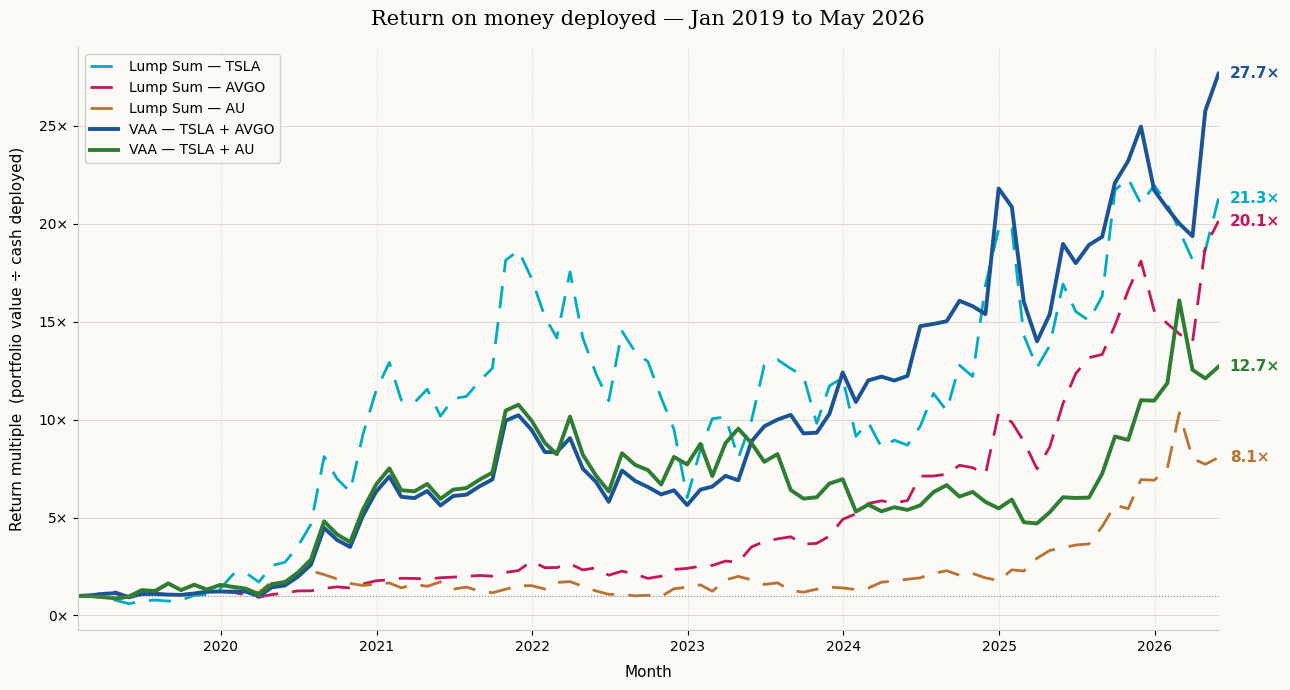

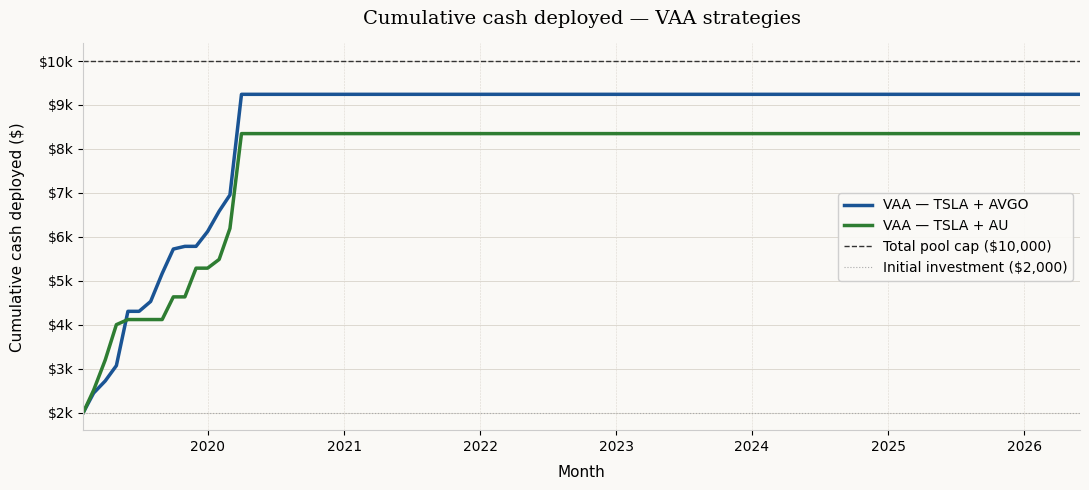


Simulation complete.


In [ ]:
# @title
# =============================================================================
# VAA + Internal Rebalancing Simulation – Full Script (Google Colab ready)
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime

# -----------------------------------------------------------------------------
# 1. Parameters
# -----------------------------------------------------------------------------
TOTAL_CASH     = 10_000
INITIAL_INVEST = 2_000
STEP           = 500
ROLLING_WEEKS  = 50
BAND           = 0.10
W_L_MIN        = 0.05
W_L_MAX        = 0.50

SIM_START  = "2019-01-01"
SIM_END    = "2026-05-31"
DATA_START = "2017-01-01"

# Chart colours
C_TSLA = "#00ACC1"
C_AVGO = "#C2185B"
C_AU   = "#B87333"
C_VTA  = "#1a5494"
C_VTG  = "#2e7d32"

# -----------------------------------------------------------------------------
# 2. Download and prepare price data
# -----------------------------------------------------------------------------
print("Downloading price data …")
raw = yf.download(
    ["TSLA", "AVGO", "AU"],
    start=DATA_START,
    end=SIM_END,
    auto_adjust=True,
    progress=False,
)["Close"]

raw = raw.dropna()

weekly = raw.resample("W-FRI").last().dropna()
monthly_all = raw.resample("ME").last().dropna()
sim_mask = (monthly_all.index >= SIM_START) & (monthly_all.index <= SIM_END)
monthly = monthly_all[sim_mask].copy()

N = len(monthly)
dates = monthly.index.tolist()

tsla_m = monthly["TSLA"].values
avgo_m = monthly["AVGO"].values
au_m   = monthly["AU"].values

print(f"Simulation months : {N}")
print(f"From              : {dates[0].date()}")
print(f"To                : {dates[-1].date()}")
print(f"TSLA start price  : ${tsla_m[0]:.2f}   end: ${tsla_m[-1]:.2f}")
print(f"AVGO start price  : ${avgo_m[0]:.2f}   end: ${avgo_m[-1]:.2f}")
print(f"AU   start price  : ${au_m[0]:.2f}    end: ${au_m[-1]:.2f}\n")

# -----------------------------------------------------------------------------
# 3. Rolling statistics helper
# -----------------------------------------------------------------------------
def _rolling_stats(p1_wk: pd.Series, p2_wk: pd.Series,
                   target_dates: list, window: int = 50):
    common = p1_wk.index.intersection(p2_wk.index)
    p1 = p1_wk.loc[common].values
    p2 = p2_wk.loc[common].values
    wk_dates = p1_wk.loc[common].index

    r1 = np.concatenate(([np.nan], np.diff(np.log(p1))))
    r2 = np.concatenate(([np.nan], np.diff(np.log(p2))))

    nw = len(r1)
    mu1  = np.full(nw, np.nan)
    mu2  = np.full(nw, np.nan)
    sig1 = np.full(nw, np.nan)
    sig2 = np.full(nw, np.nan)
    rho  = np.full(nw, np.nan)

    for i in range(window, nw):
        sl = slice(i - window + 1, i + 1)
        mu1[i]  = np.nanmean(r1[sl])
        mu2[i]  = np.nanmean(r2[sl])
        sig1[i] = np.nanstd(r1[sl], ddof=1)
        sig2[i] = np.nanstd(r2[sl], ddof=1)
        v = ~(np.isnan(r1[sl]) | np.isnan(r2[sl]))
        if v.sum() >= 2:
            rho[i] = np.corrcoef(r1[sl][v], r2[sl][v])[0, 1]

    def _map(arr):
        out = []
        for td in target_dates:
            mask = wk_dates <= td
            out.append(arr[np.where(mask)[0][-1]] if mask.any() else np.nan)
        return np.array(out)

    def _ffill(arr):
        out = arr.copy()
        last = np.nan
        for i in range(len(out)):
            if not np.isnan(out[i]):
                last = out[i]
            elif not np.isnan(last):
                out[i] = last
        return out

    return (_ffill(_map(mu1)),  _ffill(_map(mu2)),
            _ffill(_map(sig1)), _ffill(_map(sig2)),
            _ffill(_map(rho)))

# -----------------------------------------------------------------------------
# 4. Compute rolling stats for both pairs
# -----------------------------------------------------------------------------
print("Computing rolling statistics for TSLA + AVGO …")
mu_t_ta, mu_a_ta, sig_t_ta, sig_a_ta, rho_ta = _rolling_stats(
    weekly["TSLA"], weekly["AVGO"], dates, ROLLING_WEEKS)

print("Computing rolling statistics for TSLA + AU …")
mu_t_tg, mu_g_tg, sig_t_tg, sig_g_tg, rho_tg = _rolling_stats(
    weekly["TSLA"], weekly["AU"],   dates, ROLLING_WEEKS)
print()

# -----------------------------------------------------------------------------
# 5. Weight formula (corrected order)
# -----------------------------------------------------------------------------
def _weights(er1: float, er2: float,
             sig1: float, sig2: float,
             rho: float,
             w_min: float = W_L_MIN,
             w_max: float = W_L_MAX):
    if any(np.isnan([er1, er2, sig1, sig2, rho])):
        return 0.70, 0.30

    if er1 >= er2:
        w_l = (er2 / er1) * (sig1 / (sig1 + sig2)) * (1 - rho)
        w_l = float(np.clip(w_l, w_min, w_max))
        return 1 - w_l, w_l
    else:
        w_l = (er1 / er2) * (sig2 / (sig2 + sig1)) * (1 - rho)
        w_l = float(np.clip(w_l, w_min, w_max))
        return w_l, 1 - w_l

def w_avgo(i):
    return _weights(mu_t_ta[i], mu_a_ta[i],
                    sig_t_ta[i], sig_a_ta[i], rho_ta[i])

def w_au(i):
    return _weights(mu_t_tg[i], mu_g_tg[i],
                    sig_t_tg[i], sig_g_tg[i], rho_tg[i])

# -----------------------------------------------------------------------------
# 6. Lump sum calculation
# -----------------------------------------------------------------------------
def lump_sum(prices: np.ndarray, capital: float = TOTAL_CASH):
    shares = capital / prices[0]
    return shares * prices

ls_tsla = lump_sum(tsla_m)
ls_avgo = lump_sum(avgo_m)
ls_au   = lump_sum(au_m)

# -----------------------------------------------------------------------------
# 7. Value Averaging simulation function
# -----------------------------------------------------------------------------
def run_va(prices1, prices2, weight_fn, er1_arr, er2_arr,
           all_prices1, all_prices2,
           total_cash=TOTAL_CASH, initial_invest=INITIAL_INVEST,
           step=STEP, band=BAND):
    pool = total_cash - initial_invest
    w1_0, w2_0 = weight_fn(0)
    sh1 = initial_invest * w1_0 / prices1[0]
    sh2 = initial_invest * w2_0 / prices2[0]

    target = initial_invest
    deployed = initial_invest

    port_vals = np.empty(len(prices1))
    cum_inv   = np.empty(len(prices1))
    port_vals[0] = initial_invest
    cum_inv[0]   = initial_invest

    for i in range(1, len(prices1)):
        p1, p2 = prices1[i], prices2[i]
        port = sh1 * p1 + sh2 * p2
        w1_t, w2_t = weight_fn(i)
        er1, er2 = er1_arr[i], er2_arr[i]

        if er1 >= er2:
            val_H, val_L = sh1 * p1, sh2 * p2
            w_H, w_L = w1_t, w2_t
            is_1_H = True
        else:
            val_H, val_L = sh2 * p2, sh1 * p1
            w_H, w_L = w2_t, w1_t
            is_1_H = False

        R_tgt = w_L / w_H if w_H > 0 else np.inf
        R_act = val_L / val_H if val_H > 0 else np.inf
        breached = R_tgt > 0 and abs(R_act - R_tgt) / R_tgt > band

        skip = False
        if breached and R_act < R_tgt:
            p_H = p1 if is_1_H else p2
            hist = all_prices1 if is_1_H else all_prices2
            ma12 = np.mean(hist[max(0, i-11):i+1])
            if p_H > ma12:
                skip = True

        if breached and not skip:
            if R_act < R_tgt:
                need = port * w_L - val_L
                if need > 0:
                    if is_1_H:
                        sh1 -= need / p1
                        sh2 += need / p2
                    else:
                        sh2 -= need / p2
                        sh1 += need / p1
            else:
                need = port * w_H - val_H
                if need > 0:
                    if is_1_H:
                        sh2 -= need / p2
                        sh1 += need / p1
                    else:
                        sh1 -= need / p1
                        sh2 += need / p2
            port = sh1 * p1 + sh2 * p2

        target += step
        shortfall = max(0.0, target - port)
        if shortfall > 0 and pool > 0:
            deploy = min(shortfall, pool)
            pool -= deploy
            deployed += deploy
            w1_d, w2_d = weight_fn(i)
            sh1 += deploy * w1_d / p1
            sh2 += deploy * w2_d / p2
            port = sh1 * p1 + sh2 * p2

        port_vals[i] = port
        cum_inv[i] = deployed

    return port_vals, cum_inv

# -----------------------------------------------------------------------------
# 8. Run VAA strategies
# -----------------------------------------------------------------------------
print("Running VAA — TSLA + AVGO …")
vta_port, vta_inv = run_va(
    tsla_m, avgo_m,
    w_avgo,
    mu_t_ta, mu_a_ta,
    tsla_m, avgo_m,
)

print("Running VAA — TSLA + AU …")
vtg_port, vtg_inv = run_va(
    tsla_m, au_m,
    w_au,
    mu_t_tg, mu_g_tg,
    tsla_m, au_m,
)
print()

# -----------------------------------------------------------------------------
# 9. Results table
# -----------------------------------------------------------------------------
years = (dates[-1] - dates[0]).days / 365.25

cases = [
    ("Lump Sum — TSLA",        ls_tsla[-1],   TOTAL_CASH),
    ("Lump Sum — AVGO",        ls_avgo[-1],   TOTAL_CASH),
    ("Lump Sum — AU",          ls_au[-1],     TOTAL_CASH),
    ("VAA TSLA + AVGO",        vta_port[-1],  vta_inv[-1]),
    ("VAA TSLA + AU",          vtg_port[-1],  vtg_inv[-1]),
]

sep = "─" * 80
print(sep)
print(f" Simulation results  |  {dates[0].strftime('%b %Y')} → {dates[-1].strftime('%b %Y')}  ({years:.1f} years)")
print(sep)
print(f"  {'Case':<24}  {'Deployed':>12}  {'Final value':>13}  {'Multiple':>10}  {'CAGR':>8}")
print(sep)
for name, fv, iv in cases:
    mult = fv / iv
    c    = (mult ** (1 / years) - 1) * 100
    print(f"  {name:<24}  ${iv:>11,.0f}  ${fv:>12,.0f}  {mult:>9.1f}×  {c:>7.1f}%")
print(sep)
print("  Notes:")
print("  · Lump sum: all $10,000 invested on the first day, no further action.")
print("  · VAA cases: $2,000 invested on day 1; up to $8,000 more drawn from")
print("    the reserve as monthly shortfalls arise (hard cap $10,000 total).")
print("  · AVGO prices include backward dividend adjustment (via yfinance")
print("    auto_adjust=True), so its return reflects total return, not price only.")
print("  · VAA return multiple = final portfolio value ÷ cash actually deployed.")
print(sep)
print()

# -----------------------------------------------------------------------------
# 10. Chart – Return multiples over time
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("#faf9f6")
ax.set_facecolor("#faf9f6")

ax.plot(dates, ls_tsla / TOTAL_CASH, color=C_TSLA, lw=2.0,
        ls="--", dashes=(8,5), label="Lump Sum — TSLA")
ax.plot(dates, ls_avgo / TOTAL_CASH, color=C_AVGO, lw=2.0,
        ls="--", dashes=(8,5), label="Lump Sum — AVGO")
ax.plot(dates, ls_au   / TOTAL_CASH, color=C_AU,   lw=2.0,
        ls="--", dashes=(8,5), label="Lump Sum — AU")
ax.plot(dates, vta_port / vta_inv, color=C_VTA, lw=2.8, ls="-",
        label="VAA — TSLA + AVGO")
ax.plot(dates, vtg_port / vtg_inv, color=C_VTG, lw=2.8, ls="-",
        label="VAA — TSLA + AU")
ax.axhline(1, color="#888", lw=0.8, ls=":")

# annotations at final month
for vals, inv, col, label in [
    (ls_tsla, TOTAL_CASH, C_TSLA, f"{ls_tsla[-1]/TOTAL_CASH:.1f}×"),
    (ls_avgo, TOTAL_CASH, C_AVGO, f"{ls_avgo[-1]/TOTAL_CASH:.1f}×"),
    (ls_au,   TOTAL_CASH, C_AU,   f"{ls_au[-1]/TOTAL_CASH:.1f}×"),
    (vta_port, vta_inv,  C_VTA,  f"{vta_port[-1]/vta_inv[-1]:.1f}×"),
    (vtg_port, vtg_inv,  C_VTG,  f"{vtg_port[-1]/vtg_inv[-1]:.1f}×"),
]:
    y = vals[-1] / (inv[-1] if not isinstance(inv, (int, float)) else inv)
    ax.annotate(label, xy=(dates[-1], y), xytext=(8, 0),
                textcoords="offset points",
                color=col, fontsize=11, fontweight="bold", va="center")

ax.set_title("Return on money deployed — Jan 2019 to May 2026",
             fontsize=15, pad=16, fontfamily="serif")
ax.set_ylabel("Return multiple  (portfolio value ÷ cash deployed)",
              fontsize=11, labelpad=10)
ax.set_xlabel("Month", fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}×"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="both", labelsize=10)
ax.grid(axis="y", color="#ddd8d0", linewidth=0.7, linestyle="-")
ax.grid(axis="x", color="#ddd8d0", linewidth=0.4, linestyle="--")
ax.set_xlim(dates[0], dates[-1])
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#ccc")

legend_elements = [
    Line2D([0],[0], color=C_TSLA, lw=2.0, ls="--", dashes=(8,5), label="Lump Sum — TSLA"),
    Line2D([0],[0], color=C_AVGO, lw=2.0, ls="--", dashes=(8,5), label="Lump Sum — AVGO"),
    Line2D([0],[0], color=C_AU,   lw=2.0, ls="--", dashes=(8,5), label="Lump Sum — AU"),
    Line2D([0],[0], color=C_VTA,  lw=2.8, ls="-",                label="VAA — TSLA + AVGO"),
    Line2D([0],[0], color=C_VTG,  lw=2.8, ls="-",                label="VAA — TSLA + AU"),
]
ax.legend(handles=legend_elements, loc="upper left",
          frameon=True, framealpha=0.92, fontsize=10,
          edgecolor="#ccc", facecolor="#faf9f6")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 11. Supplementary chart – cash deployed over time
# -----------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(11, 5))
fig2.patch.set_facecolor("#faf9f6")
ax2.set_facecolor("#faf9f6")

ax2.plot(dates, vta_inv, color=C_VTA, lw=2.5, label="VAA — TSLA + AVGO")
ax2.plot(dates, vtg_inv, color=C_VTG, lw=2.5, label="VAA — TSLA + AU")
ax2.axhline(TOTAL_CASH, color="#333", lw=1, ls="--",
            label=f"Total pool cap (${TOTAL_CASH:,})")
ax2.axhline(INITIAL_INVEST, color="#aaa", lw=0.8, ls=":",
            label=f"Initial investment (${INITIAL_INVEST:,})")

ax2.set_title("Cumulative cash deployed — VAA strategies",
              fontsize=14, pad=14, fontfamily="serif")
ax2.set_ylabel("Cumulative cash deployed ($)", fontsize=11, labelpad=10)
ax2.set_xlabel("Month", fontsize=11, labelpad=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"${y/1000:.0f}k"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(axis="both", labelsize=10)
ax2.grid(axis="y", color="#ddd8d0", linewidth=0.7)
ax2.grid(axis="x", color="#ddd8d0", linewidth=0.4, linestyle="--")
ax2.set_xlim(dates[0], dates[-1])
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#ccc")
ax2.legend(fontsize=10, frameon=True, framealpha=0.92,
           edgecolor="#ccc", facecolor="#faf9f6")

plt.tight_layout()
plt.show()

print("\nSimulation complete.")